In [ ]:

!pip -q install "transformers>=4.44,<4.49" "datasets<3.0" "accelerate>=0.33" \
    "bitsandbytes>=0.43" "seqeval" "scikit-learn" "matplotlib" "pandas" "scipy"


import torch, os, gc, json, math, time, numpy as np, pandas as pd
print("CUDA:", torch.cuda.is_available(),
      torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("VRAM GB:", round(torch.cuda.get_device_properties(0).total_memory/1e9,1)
      if torch.cuda.is_available() else 0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
os.makedirs("outputs", exist_ok=True); os.makedirs("plots", exist_ok=True)

def free():
    gc.collect(); torch.cuda.empty_cache()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 33.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.26.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
diffusers 0.40.0 requires huggingface

In [ ]:

MODELS = {
    "MuRIL":     "google/muril-base-cased",
    "IndicBERT": "ai4bharat/IndicBERTv2-MLM-only",
    "XLM-R":     "FacebookAI/xlm-roberta-base",
}
LANGS = ["hi", "ta", "te", "bn"]        # Hindi(ref), Tamil, Telugu, Bengali
NUM_ENC_LAYERS = 12
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)


MAX_LEN_CLS  = 128
MAX_LEN_NER  = 128
TRAIN_SUBSET = 8000
EVAL_SUBSET  = 2000
BATCH_TRAIN  = 16
BATCH_EVAL   = 32
EPOCHS_HEAD  = 5
EPOCHS_FULL  = 3
NER_LABELS = ["O","B-PER","I-PER","B-LOC","I-LOC","B-ORG","I-ORG"]

In [ ]:

from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          AutoModelForTokenClassification)

def load_tokenizer(model_id):
    return AutoTokenizer.from_pretrained(model_id, use_fast=True)

def load_cls_model(model_id, num_labels=3):
    return AutoModelForSequenceClassification.from_pretrained(
        model_id, num_labels=num_labels).to(DEVICE)

def load_ner_model(model_id, num_labels=len(NER_LABELS)):
    return AutoModelForTokenClassification.from_pretrained(
        model_id, num_labels=num_labels,
        id2label={i:l for i,l in enumerate(NER_LABELS)},
        label2id={l:i for i,l in enumerate(NER_LABELS)}).to(DEVICE)

# smoke test (loads and frees each model)
for name,mid in MODELS.items():
    tok = load_tokenizer(mid); m = load_cls_model(mid)
    print(name, "params(M):", round(sum(p.numel() for p in m.parameters())/1e6,1))
    del m; free()

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at FacebookAI/xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


XLM-R params(M): 278.0


In [ ]:

import torch.nn as nn
from transformers import AutoModel

class MeanPoolClassifier(nn.Module):
    def __init__(self, model_id, num_labels):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_id)
        hidden = self.backbone.config.hidden_size
        self.norm = nn.LayerNorm(hidden)
        self.classifier = nn.Linear(hidden, num_labels)
        self.num_labels = num_labels

    @property
    def config(self):
        return self.backbone.config

    def mean_pool(self, last_hidden, attention_mask):
        mask = attention_mask.unsqueeze(-1).to(last_hidden.dtype)
        summed = (last_hidden * mask).sum(1)
        counts = mask.sum(1).clamp(min=1e-4)
        return summed / counts

    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None,
                labels=None, **kwargs):
        kw = dict(input_ids=input_ids, attention_mask=attention_mask)
        if token_type_ids is not None and "roberta" not in self.backbone.config.model_type:
            kw["token_type_ids"] = token_type_ids
        out = self.backbone(**kw)
        pooled = self.mean_pool(out.last_hidden_state, attention_mask)
        pooled = self.norm(pooled)
        logits = self.classifier(pooled)
        loss = None
        if labels is not None:
            loss = F.cross_entropy(logits.float(), labels)
        from transformers.modeling_outputs import SequenceClassifierOutput
        return SequenceClassifierOutput(loss=loss, logits=logits)


def load_cls_model(model_id, num_labels=3, use_mean_pool=True):
    if use_mean_pool:
        return MeanPoolClassifier(model_id, num_labels).to(DEVICE)
    return AutoModelForSequenceClassification.from_pretrained(
        model_id, num_labels=num_labels).to(DEVICE)

In [ ]:

from datasets import load_dataset

def get_xnli(lang, tokenizer, split, n=None):
    ds = load_dataset("Divyanshu/indicxnli", lang, split=split)
    if n: ds = ds.select(range(min(n, len(ds))))
    def enc(b):
        out = tokenizer(b["premise"], b["hypothesis"], truncation=True,
                        max_length=MAX_LEN_CLS, padding="max_length")
        out["labels"] = b["label"]; return out
    return ds.map(enc, batched=True, remove_columns=ds.column_names)

def get_naamapadam(lang, tokenizer, split, n=None):
    ds = load_dataset("ai4bharat/naamapadam", lang, split=split, trust_remote_code=True)
    if n: ds = ds.select(range(min(n, len(ds))))
    def enc(b):
        tok = tokenizer(b["words"], truncation=True, max_length=MAX_LEN_NER,
                        padding="max_length", is_split_into_words=True)
        labels=[]
        for i,lab in enumerate(b["ner"]):
            wids = tok.word_ids(batch_index=i); prev=None; lids=[]
            for w in wids:
                if w is None: lids.append(-100)
                elif w!=prev:  lids.append(lab[w])
                else:          lids.append(-100)   # label only first subword
                prev=w
            labels.append(lids)
        tok["labels"]=labels; return tok
    return ds.map(enc, batched=True, remove_columns=ds.column_names)


In [ ]:

from torch.utils.data import DataLoader
from transformers import default_data_collator, get_linear_schedule_with_warmup
import torch.nn.functional as F

def freeze_backbone(model):
    for n,p in model.named_parameters():
        if "classifier" not in n and not n.startswith("cls"):
            p.requires_grad = False
    return model

def train(model, train_ds, epochs, lr=None, frozen=False, warmup_ratio=0.1):
    if frozen:
        for n, p in model.named_parameters():
            if "classifier" not in n and "norm" not in n:
                p.requires_grad = False
        lr = lr or 1e-3
    else:
        lr = lr or 2e-5

    model.train()
    dl = DataLoader(train_ds, batch_size=BATCH_TRAIN, shuffle=True,
                    collate_fn=default_data_collator)
    params = [p for p in model.parameters() if p.requires_grad]
    n_trainable = sum(p.numel() for p in params)
    print(f"Trainable params: {n_trainable:,}  |  lr={lr}  |  frozen={frozen}")

    opt = torch.optim.AdamW(params, lr=lr, weight_decay=0.01)
    total_steps = len(dl) * epochs
    sch = get_linear_schedule_with_warmup(
        opt, num_warmup_steps=int(total_steps * warmup_ratio),
        num_training_steps=total_steps)

    num_labels = getattr(model, "num_labels", None) or model.config.num_labels

    for ep in range(epochs):
        total_loss, n_batches = 0.0, 0
        pred_counts = torch.zeros(num_labels)
        for batch in dl:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            out = model(**batch)
            out.loss.backward()
            torch.nn.utils.clip_grad_norm_(params, 1.0)
            opt.step(); sch.step(); opt.zero_grad()
            total_loss += out.loss.item(); n_batches += 1
            with torch.no_grad():
                preds = out.logits.argmax(-1).cpu()
                for p in preds: pred_counts[p] += 1
        print(f"  epoch {ep}: avg_loss={total_loss/n_batches:.4f}  "
              f"pred_distribution={pred_counts.tolist()}")

        if pred_counts.max() >= 0.95 * pred_counts.sum() and ep >= 1:
            print("  !! Collapse detected — predictions stuck on one class. "
                  "Consider lowering lr further (e.g. 1e-5) or checking data.")
    return model

In [ ]:

from sklearn.metrics import accuracy_score
from seqeval.metrics import f1_score as seq_f1

@torch.no_grad()
def eval_cls(model, ds):
    model.eval(); dl=DataLoader(ds,batch_size=BATCH_EVAL,collate_fn=default_data_collator)
    P,Y=[],[]
    for b in dl:
        b={k:v.to(DEVICE) for k,v in b.items()}
        logits=model(**b).logits
        P+=logits.argmax(-1).cpu().tolist(); Y+=b["labels"].cpu().tolist()
    return accuracy_score(Y,P)

@torch.no_grad()
def eval_ner(model, ds):
    model.eval(); dl=DataLoader(ds,batch_size=BATCH_EVAL,collate_fn=default_data_collator)
    preds,gold=[],[]
    for b in dl:
        b={k:v.to(DEVICE) for k,v in b.items()}
        logits=model(**b).logits.argmax(-1).cpu().tolist()
        labs=b["labels"].cpu().tolist()
        for pr,la in zip(logits,labs):
            preds.append([NER_LABELS[p] for p,l in zip(pr,la) if l!=-100])
            gold.append([NER_LABELS[l] for l in la if l!=-100])
    return seq_f1(gold,preds)

In [ ]:

import bitsandbytes as bnb
import torch.nn as nn
from copy import deepcopy

def _module_paths_for_layer(model, layer_idx):
    """Names of nn.Linear inside encoder layer `layer_idx`
    (works for BERT '.layer.{i}.' and RoBERTa '.layer.{i}.')."""
    return [n for n,m in model.named_modules()
            if isinstance(m, nn.Linear) and f".layer.{layer_idx}." in n]

def _get_parent(model, dotted):
    parts=dotted.split("."); obj=model
    for p in parts[:-1]: obj=getattr(obj,p)
    return obj, parts[-1]

def quantize_linear_int8(model, names):
    for name in names:
        parent, attr = _get_parent(model, name); old = getattr(parent, attr)
        new = bnb.nn.Linear8bitLt(old.in_features, old.out_features,
              bias=old.bias is not None, has_fp16_weights=False, threshold=6.0)
        new.weight = bnb.nn.Int8Params(old.weight.data.clone(),
                     requires_grad=False, has_fp16_weights=False)
        if old.bias is not None: new.bias = nn.Parameter(old.bias.data.clone())
        setattr(parent, attr, new)
    return model.to(DEVICE)

def layerwise_sensitivity(base_model_fp, eval_fn, eval_ds_by_lang, granularity="whole"):
    """Returns S[layer][lang] = baseline_metric - quantized_metric."""
    base_metric = {lg: eval_fn(base_model_fp, ds) for lg,ds in eval_ds_by_lang.items()}
    langs=list(eval_ds_by_lang.keys()); S = np.zeros((NUM_ENC_LAYERS, len(langs)))
    for li in range(NUM_ENC_LAYERS):
        m = deepcopy(base_model_fp).to("cpu")
        names=_module_paths_for_layer(m, li)
        if granularity=="attention":
            names=[n for n in names if "attention" in n]
        elif granularity=="ffn":
            names=[n for n in names if ("intermediate" in n
                   or ("output" in n and "attention" not in n))]
        m = quantize_linear_int8(m, names)
        for j,lg in enumerate(langs):
            S[li,j] = base_metric[lg] - eval_fn(m, eval_ds_by_lang[lg])
        del m; free()
    return S, base_metric, langs


In [ ]:

def quantize_linear_int4(model, names, quant_type="nf4"):
    for name in names:
        parent, attr = _get_parent(model, name); old = getattr(parent, attr)
        new = bnb.nn.Linear4bit(old.in_features, old.out_features,
              bias=old.bias is not None, compute_dtype=torch.float16,
              quant_type=quant_type)
        new.weight = bnb.nn.Params4bit(old.weight.data.clone(),
                     requires_grad=False, quant_type=quant_type)
        if old.bias is not None: new.bias = nn.Parameter(old.bias.data.clone())
        setattr(parent, attr, new)
    return model.to(DEVICE)


def manual_int4_fakequant_(model, names):
    for name in names:
        parent, attr = _get_parent(model, name); lin = getattr(parent, attr)
        w = lin.weight.data
        s = w.abs().max()/7.0
        lin.weight.data = (torch.clamp(torch.round(w/s), -8, 7)*s).to(w.dtype)
    return model

In [ ]:

GPTQ_APPLICABLE = False
print("GPTQ applicable to BERT encoders:", GPTQ_APPLICABLE)

GPTQ applicable to BERT encoders: False


In [ ]:

AWQ_APPLICABLE = False
print("AWQ applicable to BERT encoders:", AWQ_APPLICABLE)


AWQ applicable to BERT encoders: False


In [ ]:

import matplotlib.pyplot as plt

def plot_heatmap(S, langs, title, fname):
    fig,ax=plt.subplots(figsize=(6,5))
    im=ax.imshow(S, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(langs))); ax.set_xticklabels(langs)
    ax.set_yticks(range(S.shape[0])); ax.set_yticklabels([f"L{i}" for i in range(S.shape[0])])
    ax.set_xlabel("Language"); ax.set_ylabel("Encoder layer"); ax.set_title(title)
    cbar=fig.colorbar(im); cbar.set_label("Metric drop (baseline − quantized)")
    for i in range(S.shape[0]):
        for j in range(S.shape[1]):
            ax.text(j,i,f"{S[i,j]:.1f}",ha="center",va="center",color="white",fontsize=7)
    fig.tight_layout(); fig.savefig(f"plots/{fname}", dpi=300); plt.show()

In [ ]:

from scipy.stats import pearsonr, spearmanr
from scipy.spatial.distance import jensenshannon

def correlation_analysis(S, langs):
    n=len(langs); pear=np.eye(n); spear=np.eye(n); js=np.zeros((n,n))
    for a in range(n):
        for b in range(n):
            pear[a,b]=pearsonr(S[:,a],S[:,b])[0]
            spear[a,b]=spearmanr(S[:,a],S[:,b])[0]
            pa=np.abs(S[:,a])/(np.abs(S[:,a]).sum()+1e-9)
            pb=np.abs(S[:,b])/(np.abs(S[:,b]).sum()+1e-9)
            js[a,b]=jensenshannon(pa,pb)
    idx=langs
    return (pd.DataFrame(pear,index=idx,columns=idx),
            pd.DataFrame(spear,index=idx,columns=idx),
            pd.DataFrame(js,index=idx,columns=idx))

In [ ]:

def build_policy(S, target_avg_bits=6.0, fairness="mean"):
    """Assign {4,8,16} bits per layer under an average-bit budget.
       fairness='worst' minimizes the worst-language drop."""
    score = S.max(axis=1) if fairness=="worst" else S.mean(axis=1)
    order = np.argsort(score)
    bits = np.full(NUM_ENC_LAYERS, 8)
    for li in order[:NUM_ENC_LAYERS//3]:  bits[li]=4
    for li in order[-NUM_ENC_LAYERS//3:]: bits[li]=16
    while bits.mean() > target_avg_bits:
        cand=[i for i in order if bits[i]==8]
        if not cand: break
        bits[cand[0]]=4
    return bits

def apply_policy(base_model_fp, bits):
    m=deepcopy(base_model_fp).to("cpu")
    for li in range(NUM_ENC_LAYERS):
        names=_module_paths_for_layer(m, li)
        if   bits[li]==8: m=quantize_linear_int8(m,names)
        elif bits[li]==4: m=quantize_linear_int4(m,names)
        # bits==16 -> leave fp16
    return m.to(DEVICE)

In [ ]:

def all_layer_names(model):
    return [n for li in range(NUM_ENC_LAYERS) for n in _module_paths_for_layer(model,li)]

def comparison_table(base_fp, eval_fn, eval_ds_by_lang, S):
    langs=list(eval_ds_by_lang.keys()); rows=[]
    def rowfor(tag, model):
        return {"config":tag, **{lg:eval_fn(model,eval_ds_by_lang[lg]) for lg in langs}}
    rows.append(rowfor("fp16", base_fp)); free()
    m8=quantize_linear_int8(deepcopy(base_fp).to("cpu"), all_layer_names(base_fp))
    rows.append(rowfor("uniform-int8", m8)); del m8; free()
    m4=quantize_linear_int4(deepcopy(base_fp).to("cpu"), all_layer_names(base_fp))
    rows.append(rowfor("uniform-int4", m4)); del m4; free()
    mp=apply_policy(base_fp, build_policy(S,6.0,"mean"))
    rows.append(rowfor("mixed-6bit-mean", mp)); del mp; free()
    mpf=apply_policy(base_fp, build_policy(S,6.0,"worst"))
    rows.append(rowfor("mixed-6bit-fair", mpf)); del mpf; free()
    return pd.DataFrame(rows)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Trainable params: 3,843  |  lr=0.001  |  frozen=True
  epoch 0: avg_loss=1.0917  pred_distribution=[2603.0, 841.0, 4556.0]
  epoch 1: avg_loss=1.0589  pred_distribution=[2997.0, 763.0, 4240.0]
  epoch 2: avg_loss=1.0408  pred_distribution=[2898.0, 849.0, 4253.0]
  epoch 3: avg_loss=1.0280  pred_distribution=[2992.0, 737.0, 4271.0]
  epoch 4: avg_loss=1.0202  pred_distribution=[2986.0, 833.0, 4181.0]
Sample logits (should NOT be identical rows):
tensor([[-0.2456, -0.6417, -0.0288],
        [-0.3329, -0.8116,  0.1559],
        [-0.1012, -0.6102, -0.2729],
        [-0.8587, -0.0589, -0.0507],
        [-0.3819, -0.2463, -0.3588],
        [-0.3386, -0.2856, -0.3475],
        [-0.5560, -0.2195, -0.2355],
        [-0.6269, -0.6100,  0.1663]])
Sample preds: [2, 2, 0, 2, 1, 1, 1, 2]
Sample true: [1, 2, 0, 1, 2, 0, 2, 0]


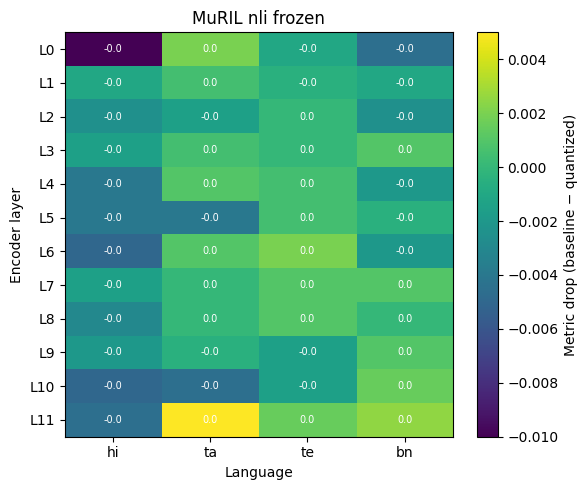

            config      hi      ta      te      bn
0             fp16  0.4635  0.4110  0.4230  0.4395
1     uniform-int8  0.4740  0.4090  0.4250  0.4440
2     uniform-int4  0.4625  0.4130  0.4380  0.4335
3  mixed-6bit-mean  0.4615  0.4175  0.4290  0.4325
4  mixed-6bit-fair  0.4570  0.4335  0.4415  0.4255


In [ ]:

def run_experiment(model_name, task="nli", variant="frozen"):
    mid=MODELS[model_name]; tok=load_tokenizer(mid)
    if task=="nli":
        train_ds=get_xnli("hi",tok,"train",TRAIN_SUBSET)
        eval_ds={lg:get_xnli(lg,tok,"validation",EVAL_SUBSET) for lg in LANGS}
        model=load_cls_model(mid,3); eval_fn=eval_cls
    else:
        train_ds=get_naamapadam("hi",tok,"train",TRAIN_SUBSET)
        eval_ds={lg:get_naamapadam(lg,tok,"validation",EVAL_SUBSET) for lg in LANGS}
        model=load_ner_model(mid); eval_fn=eval_ner
    model=train(model, train_ds,
                EPOCHS_HEAD if variant=="frozen" else EPOCHS_FULL,
                frozen=(variant=="frozen"))


    model.eval()
    sample = next(iter(DataLoader(eval_ds["hi"], batch_size=8, collate_fn=default_data_collator)))
    sample = {k:v.to(DEVICE) for k,v in sample.items()}
    with torch.no_grad():
        logits = model(**sample).logits
    print("Sample logits (should NOT be identical rows):")
    print(logits.cpu())
    print("Sample preds:", logits.argmax(-1).cpu().tolist())
    print("Sample true:", sample["labels"].cpu().tolist())
    model_fp=model.half()
    S,base,langs=layerwise_sensitivity(model_fp, eval_fn, eval_ds, "whole")
    plot_heatmap(S, langs, f"{model_name} {task} {variant}",
                 f"heat_{model_name}_{task}_{variant}.png")
    pear,spear,js=correlation_analysis(S,langs)
    cmp=comparison_table(model_fp, eval_fn, eval_ds, S)
    pd.DataFrame(S,columns=langs,index=[f"L{i}" for i in range(NUM_ENC_LAYERS)])\
        .to_csv(f"outputs/S_{model_name}_{task}_{variant}.csv")
    pear.to_csv(f"outputs/pearson_{model_name}_{task}_{variant}.csv")
    cmp.to_csv(f"outputs/cmp_{model_name}_{task}_{variant}.csv", index=False)
    print(cmp); del model, model_fp; free()
    return S, cmp


S, cmp = run_experiment("MuRIL", "nli", "frozen")


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Trainable params: 237,560,067  |  lr=2e-05  |  frozen=False
  epoch 0: avg_loss=0.9466  pred_distribution=[3095.0, 1235.0, 3670.0]
  epoch 1: avg_loss=0.6617  pred_distribution=[2797.0, 2256.0, 2947.0]
  epoch 2: avg_loss=0.4636  pred_distribution=[2756.0, 2294.0, 2950.0]
Sample logits (should NOT be identical rows):
tensor([[-2.2496,  1.9278, -0.2859],
        [-2.1830, -2.3720,  3.2568],
        [ 1.8979, -1.6952, -1.3129],
        [-2.6292,  0.8999,  0.9057],
        [ 0.9838, -2.3933, -0.0147],
        [ 1.6354, -1.8518, -0.9914],
        [-3.1779, -0.0080,  1.8128],
        [ 1.3373, -0.0053, -2.4426]])
Sample preds: [1, 2, 0, 2, 0, 0, 2, 0]
Sample true: [1, 2, 0, 1, 2, 0, 2, 0]


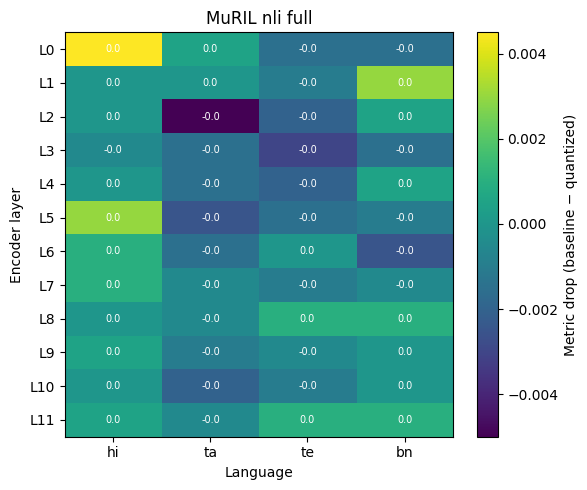

            config      hi      ta      te      bn
0             fp16  0.7230  0.6830  0.6730  0.7015
1     uniform-int8  0.7225  0.6900  0.6735  0.7025
2     uniform-int4  0.6905  0.6495  0.6315  0.6490
3  mixed-6bit-mean  0.6970  0.6540  0.6405  0.6555
4  mixed-6bit-fair  0.7095  0.6560  0.6450  0.6680


In [ ]:
S_full, cmp_full = run_experiment("MuRIL", "nli", "full")

In [ ]:


import pandas as pd
import numpy as np

def full_layer_report(model_fp, eval_fn, eval_ds_by_lang, model_name="MuRIL",
                      task="nli", variant="full", precision="int4"):
    """
    Runs layer-wise sensitivity at THREE granularities (whole layer,
    attention-only, FFN-only) so you can see whether Bengali's extra
    damage comes from attention sublayers, FFN sublayers, or both.
    Returns a dict of DataFrames + saves CSVs/plots.
    """
    quantize_fn = quantize_linear_int8 if precision == "int8" else quantize_linear_int4
    results = {}

    for granularity in ["whole", "attention", "ffn"]:
        print(f"\n=== {model_name} | {task} | {variant} | {precision} | granularity={granularity} ===")
        S, base_metric, langs = layerwise_sensitivity_custom(
            model_fp, eval_fn, eval_ds_by_lang, granularity, quantize_fn)
        df = pd.DataFrame(S, columns=langs,
                          index=[f"L{i}" for i in range(NUM_ENC_LAYERS)])
        results[granularity] = df

        # Save table
        fname = f"outputs/layerwise_{model_name}_{task}_{variant}_{precision}_{granularity}.csv"
        df.to_csv(fname)
        print(df.round(4))

        # Heatmap
        plot_heatmap(S, langs,
                    f"{model_name} {task} {variant} {precision} ({granularity})",
                    f"heat_{model_name}_{task}_{variant}_{precision}_{granularity}.png")

    return results


def layerwise_sensitivity_custom(base_model_fp, eval_fn, eval_ds_by_lang,
                                  granularity, quantize_fn):
    """Same as layerwise_sensitivity but lets you pick int8 vs int4 quantize_fn."""
    base_metric = {lg: eval_fn(base_model_fp, ds) for lg, ds in eval_ds_by_lang.items()}
    langs = list(eval_ds_by_lang.keys())
    S = np.zeros((NUM_ENC_LAYERS, len(langs)))
    for li in range(NUM_ENC_LAYERS):
        m = deepcopy(base_model_fp).to("cpu")
        names = _module_paths_for_layer(m, li)
        if granularity == "attention":
            names = [n for n in names if "attention" in n]
        elif granularity == "ffn":
            names = [n for n in names if ("intermediate" in n
                     or ("output" in n and "attention" not in n))]
        m = quantize_fn(m, names)
        for j, lg in enumerate(langs):
            S[li, j] = base_metric[lg] - eval_fn(m, eval_ds_by_lang[lg])
        del m; free()
    return S, base_metric, langs




def rank_layers_per_language(df, top_k=3):
    """
    df: layers x languages DataFrame (from full_layer_report's 'whole' entry).
    Prints, for each language, the top-k most sensitive layers (biggest drop).
    """
    print("\n=== Top sensitive layers per language ===")
    ranking = {}
    for lang in df.columns:
        ranked = df[lang].sort_values(ascending=False)
        top = ranked.head(top_k)
        ranking[lang] = top
        print(f"\n{lang}:")
        for layer, drop in top.items():
            print(f"   {layer}: -{drop:.4f}")
    return ranking


def compare_languages_layer_overlap(df, top_k=3):
    """
    Do different languages rely on the SAME layers, or different ones?
    Reports Jaccard overlap of each pair's top-k sensitive layers.
    """
    top_sets = {lang: set(df[lang].sort_values(ascending=False).head(top_k).index)
               for lang in df.columns}
    langs = list(df.columns)
    print(f"\n=== Top-{top_k} layer overlap between language pairs (Jaccard) ===")
    overlap = pd.DataFrame(index=langs, columns=langs, dtype=float)
    for a in langs:
        for b in langs:
            inter = len(top_sets[a] & top_sets[b])
            union = len(top_sets[a] | top_sets[b])
            overlap.loc[a, b] = inter / union if union else 0.0
    print(overlap.round(2))
    return overlap




# `model` here should be the trained full-fine-tune model still in memory
# from your run_experiment("MuRIL", "nli", "full") call. If it's been
# garbage-collected, retrain first:
#
#   S_full, cmp_full = run_experiment("MuRIL", "nli", "full")
#
# then re-fetch the live fp16 model by re-running the training block
# manually (recommended — run_experiment deletes the model at the end):

#tok = load_tokenizer(MODELS["MuRIL"])
#train_ds = get_xnli("hi", tok, "train", TRAIN_SUBSET)
#eval_ds  = {lg: get_xnli(lg, tok, "validation", EVAL_SUBSET) for lg in LANGS}
#
#model = load_cls_model(MODELS["MuRIL"], 3, use_mean_pool=True)
#model = train(model, train_ds, EPOCHS_FULL, frozen=False)   # full fine-tune, lr=2e-5
#model_fp = model.half()
#
## Full per-layer breakdown at int4 (where you saw the real damage)
#reports = full_layer_report(model_fp, eval_cls, eval_ds,
#                            model_name="MuRIL", task="nli",
#                            variant="full", precision="int4")
#
#whole_df = reports["whole"]
#rank_layers_per_language(whole_df, top_k=3)
#compare_languages_layer_overlap(whole_df, top_k=3)
#
## Also run int8 for the "why is int8 safe but int4 isn't" comparison
#reports_int8 = full_layer_report(model_fp, eval_cls, eval_ds,
#                                 model_name="MuRIL", task="nli",
#                                 variant="full", precision="int8")

In [ ]:
def cumulative_ablation(base_model_fp, eval_fn, eval_ds_by_lang, whole_df,
                        quantize_fn=quantize_linear_int4, k_values=(1,2,4,6,8,12)):
    """
    Quantize the k MOST sensitive layers together (per the whole_df ranking),
    leave the rest fp16. Shows how damage compounds as more layers are hit.
    """
    langs = list(eval_ds_by_lang.keys())
    base_metric = {lg: eval_fn(base_model_fp, ds) for lg, ds in eval_ds_by_lang.items()}
    # Rank layers by AVERAGE sensitivity across languages (worst-first)
    avg_sensitivity = whole_df.mean(axis=1).sort_values(ascending=False)
    ranked_layers = [int(idx[1:]) for idx in avg_sensitivity.index]  # "L5" -> 5

    rows = []
    for k in k_values:
        layers_to_hit = ranked_layers[:k]
        m = deepcopy(base_model_fp).to("cpu")
        names = []
        for li in layers_to_hit:
            names += _module_paths_for_layer(m, li)
        m = quantize_fn(m, names)
        row = {"k_layers_quantized": k, "layers": layers_to_hit}
        for lg in langs:
            row[lg] = base_metric[lg] - eval_fn(m, eval_ds_by_lang[lg])
        rows.append(row)
        del m; free()
        print(f"k={k:2d}  layers={layers_to_hit}  "
              f"drops={[round(row[lg],4) for lg in langs]}")
    return pd.DataFrame(rows)

# Run it:
#cum_df = cumulative_ablation(model_fp, eval_cls, eval_ds, whole_df,
#                             quantize_fn=quantize_linear_int4)
#cum_df.to_csv("outputs/cumulative_ablation_MuRIL_nli_full_int4.csv", index=False)
#
## Plot: x = k layers quantized, y = accuracy drop, one line per language
#import matplotlib.pyplot as plt
#fig, ax = plt.subplots(figsize=(7,5))
#for lg in LANGS:
#    ax.plot(cum_df["k_layers_quantized"], cum_df[lg], marker="o", label=lg)
#ax.set_xlabel("Number of (most-sensitive) layers quantized to int4")
#ax.set_ylabel("Accuracy drop from fp16 baseline")
#ax.set_title("MuRIL NLI (full fine-tune): cumulative damage as more layers compress")
#ax.legend(); ax.grid(alpha=0.3)
#plt.tight_layout(); plt.savefig("plots/cumulative_ablation.png", dpi=300); plt.show()

In [ ]:
# Run the SAME cumulative ablation with 2 more seeds and average
def cumulative_ablation_multiseed(model_id, task_loader_fn, eval_fn,
                                  eval_ds_by_lang, seeds=(0, 1, 2),
                                  k_values=(1,2,4,6,8,12)):
    all_runs = []
    for seed in seeds:
        torch.manual_seed(seed); np.random.seed(seed)
        model = load_cls_model(model_id, 3, use_mean_pool=True)
        train_ds = task_loader_fn()
        model = train(model, train_ds, EPOCHS_FULL, frozen=False)
        model_fp = model.half()

        S, _, langs = layerwise_sensitivity_custom(
            model_fp, eval_fn, eval_ds_by_lang, "whole", quantize_linear_int4)
        whole_df = pd.DataFrame(S, columns=langs,
                                index=[f"L{i}" for i in range(NUM_ENC_LAYERS)])

        cum_df = cumulative_ablation(model_fp, eval_fn, eval_ds_by_lang, whole_df)
        cum_df["seed"] = seed
        all_runs.append(cum_df)
        del model, model_fp; free()

    combined = pd.concat(all_runs, ignore_index=True)
    summary = combined.groupby("k_layers_quantized")[list(eval_ds_by_lang.keys())].agg(["mean","std"])
    print(summary)
    combined.to_csv("outputs/cumulative_ablation_multiseed.csv", index=False)
    return combined, summary

# Run:
#combined, summary = cumulative_ablation_multiseed(
#    MODELS["MuRIL"],
#    lambda: get_xnli("hi", load_tokenizer(MODELS["MuRIL"]), "train", TRAIN_SUBSET),
#    eval_cls, eval_ds, seeds=(0,1,2))

In [ ]:
combined, summary = cumulative_ablation_multiseed(
    MODELS["MuRIL"],
    lambda: get_xnli("hi", load_tokenizer(MODELS["MuRIL"]), "train", TRAIN_SUBSET),
    eval_cls, eval_ds, seeds=(0,1,2,3,4,5),
    k_values=(1,2,4,6,8))   # drop k=12 — you've shown it's unstable, not worth the compute

Trainable params: 237,560,067  |  lr=2e-05  |  frozen=False
  epoch 0: avg_loss=0.9433  pred_distribution=[3579.0, 1530.0, 2891.0]
  epoch 1: avg_loss=0.6316  pred_distribution=[2791.0, 2212.0, 2997.0]
  epoch 2: avg_loss=0.4381  pred_distribution=[2769.0, 2216.0, 3015.0]
k= 1  layers=[5]  drops=[0.0065, 0.0025, -0.003, 0.0105]
k= 2  layers=[5, 0]  drops=[0.009, 0.004, 0.005, 0.01]
k= 4  layers=[5, 0, 7, 8]  drops=[0.015, 0.0065, 0.01, 0.0155]
k= 6  layers=[5, 0, 7, 8, 4, 1]  drops=[0.021, 0.011, 0.013, 0.019]
k= 8  layers=[5, 0, 7, 8, 4, 1, 3, 10]  drops=[0.0145, 0.0145, 0.0095, 0.0205]
k=12  layers=[5, 0, 7, 8, 4, 1, 3, 10, 2, 6, 9, 11]  drops=[0.005, 0.009, 0.005, 0.0025]
Trainable params: 237,560,067  |  lr=2e-05  |  frozen=False
  epoch 0: avg_loss=0.9564  pred_distribution=[2690.0, 1765.0, 3545.0]
  epoch 1: avg_loss=0.6634  pred_distribution=[2843.0, 2325.0, 2832.0]
  epoch 2: avg_loss=0.4765  pred_distribution=[2765.0, 2324.0, 2911.0]
k= 1  layers=[5]  drops=[0.0095, 0.006, 0.0

In [ ]:
from scipy.stats import ttest_rel
import itertools

def pairwise_language_test(combined, k=8):
    """Paired t-test between languages at a given k, using each seed's
    drop as a paired observation (same seed = same trained model)."""
    sub = combined[combined["k_layers_quantized"] == k]
    print(f"=== Paired language comparison at k={k} ===\n")
    for a, b in itertools.combinations(LANGS, 2):
        t, p = ttest_rel(sub[a].values, sub[b].values)
        direction = a if sub[a].mean() > sub[b].mean() else b
        sig = "significant" if p < 0.05 else "not significant"
        print(f"{a} vs {b}: {a}_mean={sub[a].mean():.4f}  {b}_mean={sub[b].mean():.4f}  "
              f"t={t:.2f}  p={p:.4f}  [{direction} worse, {sig}]")

#pairwise_language_test(combined, k=8)
#pairwise_language_test(combined, k=6)

In [ ]:
from datasets import load_dataset

probe = load_dataset("ai4bharat/naamapadam", "hi", split="train[:5]", trust_remote_code=True)
print("Columns:", probe.column_names)
print("Features:", probe.features)
print("Example:", probe[0])

Columns: ['tokens', 'ner_tags']
Features: {'tokens': Sequence(feature=Value(dtype='string', id=None), length=-1, id=None), 'ner_tags': Sequence(feature=ClassLabel(names=['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC'], id=None), length=-1, id=None)}
Example: {'tokens': ['सेक्टर', '55/56', 'के', 'एसएचओ', 'अरविंद', 'कुमार', 'ने', 'बताया', 'कि', 'इस', 'मामले', 'में', 'आईपीसी', 'की', 'धारा', '376', '-', 'डी', '(', 'गैंगरेप', ')', 'के', 'तहत', 'मामला', 'दर्ज', 'कर', 'लिया', 'गया', 'है', '।'], 'ner_tags': [0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}


In [ ]:
def get_naamapadam(lang, tokenizer, split, n=None):
    ds = load_dataset("ai4bharat/naamapadam", lang, split=split, trust_remote_code=True)
    if n:
        ds = ds.select(range(min(n, len(ds))))

    word_col, tag_col = "tokens", "ner_tags"   # confirmed actual schema

    def enc(b):
        tok = tokenizer(b[word_col], truncation=True, max_length=MAX_LEN_NER,
                        padding="max_length", is_split_into_words=True)
        labels = []
        for i, lab in enumerate(b[tag_col]):
            wids = tok.word_ids(batch_index=i)
            prev = None
            lids = []
            for w in wids:
                if w is None:
                    lids.append(-100)
                elif w != prev:
                    lids.append(lab[w])
                else:
                    lids.append(-100)
                prev = w
            labels.append(lids)
        tok["labels"] = labels
        return tok

    return ds.map(enc, batched=True, remove_columns=ds.column_names)



_probe = load_dataset("ai4bharat/naamapadam", "hi", split="train[:1]", trust_remote_code=True)
NER_LABELS = _probe.features["ner_tags"].feature.names
print("NER_LABELS (from dataset, authoritative):", NER_LABELS)

del _probe

Generating train split:   0%|          | 0/985787 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/867 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13460 [00:00<?, ? examples/s]

NER_LABELS (from dataset, authoritative): ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC']


In [ ]:


import pandas as pd, numpy as np, torch, gc
from copy import deepcopy

def free():
    gc.collect(); torch.cuda.empty_cache()


def get_train_eval(task, model_id, langs=LANGS, train_lang="hi"):
    tok = load_tokenizer(model_id)
    if task == "nli":
        train_ds = get_xnli(train_lang, tok, "train", TRAIN_SUBSET)
        eval_ds  = {lg: get_xnli(lg, tok, "validation", EVAL_SUBSET) for lg in langs}
    elif task == "ner":
        train_ds = get_naamapadam(train_lang, tok, "train", TRAIN_SUBSET)
        eval_ds  = {lg: get_naamapadam(lg, tok, "validation", EVAL_SUBSET) for lg in langs}
    else:
        raise ValueError(task)
    return tok, train_ds, eval_ds

def get_model_and_evalfn(task, model_id, num_labels=None):
    if task == "nli":
        model = load_cls_model(model_id, num_labels or 3, use_mean_pool=True)
        return model, eval_cls
    elif task == "ner":
        model = load_ner_model(model_id)
        return model, eval_ner
    raise ValueError(task)



EPOCHS_FULL_NER = 5
NER_WARMUP_RATIO = 0.2

def run_full_pipeline(model_name, task, seeds=(0,1,2,3,4,5),
                      k_values=(1,2,4,6,8), langs=LANGS, train_lang="hi",
                      precision="int4", epochs=None):
    model_id = MODELS[model_name]
    if epochs is None:
        epochs = EPOCHS_FULL_NER if task == "ner" else EPOCHS_FULL
    quantize_fn = quantize_linear_int8 if precision == "int8" else quantize_linear_int4

    all_runs = []
    for seed in seeds:
        print(f"\n{'='*70}\n{model_name} | {task} | seed={seed}\n{'='*70}")
        torch.manual_seed(seed); np.random.seed(seed)

        tok, train_ds, eval_ds = get_train_eval(task, model_id, langs, train_lang)
        model, eval_fn = get_model_and_evalfn(task, model_id)
        warmup = NER_WARMUP_RATIO if task == "ner" else 0.1
        model = train(model, train_ds, epochs, frozen=False, warmup_ratio=warmup)
        model_fp = model.half()

        base_scores = {lg: eval_fn(model_fp, ds) for lg, ds in eval_ds.items()}
        print("Baseline scores:", {k: round(v,4) for k,v in base_scores.items()})


        if min(base_scores.values()) < 0.3:
            print(f"  !! REJECTING seed={seed}: baseline too low "
                  f"({min(base_scores.values()):.4f}) — training failed, skipping ablation")
            del model, model_fp; free()
            continue

        S, _, out_langs = layerwise_sensitivity_custom(
            model_fp, eval_fn, eval_ds, "whole", quantize_fn)
        whole_df = pd.DataFrame(S, columns=out_langs,
                                index=[f"L{i}" for i in range(NUM_ENC_LAYERS)])
        cum_df = cumulative_ablation(model_fp, eval_fn, eval_ds, whole_df,
                                     quantize_fn=quantize_fn, k_values=k_values)
        cum_df["seed"] = seed; cum_df["model"] = model_name
        cum_df["task"] = task; cum_df["precision"] = precision
        all_runs.append(cum_df)
        whole_df.to_csv(f"outputs/S_{model_name}_{task}_{precision}_seed{seed}.csv")
        del model, model_fp; free()

    combined = pd.concat(all_runs, ignore_index=True)
    n_valid = combined["seed"].nunique()
    print(f"\n{n_valid}/{len(seeds)} seeds produced valid results")
    summary = combined.groupby("k_layers_quantized")[langs].agg(["mean","std"])
    combined.to_csv(f"outputs/cumulative_{model_name}_{task}_{precision}_multiseed.csv",
                    index=False)
    summary.to_csv(f"outputs/summary_{model_name}_{task}_{precision}.csv")
    print(summary)
    return combined, summary



def top1_layer_consistency(model_name, task, precision="int4", seeds=(0,1,2,3,4,5)):
    """Reads back the saved per-seed S matrices and reports which layer
    was picked as most sensitive (k=1) each time."""
    picks = []
    for seed in seeds:
        df = pd.read_csv(f"outputs/S_{model_name}_{task}_{precision}_seed{seed}.csv",
                         index_col=0)
        avg_sensitivity = df.mean(axis=1)
        top_layer = avg_sensitivity.idxmax()
        picks.append(top_layer)
    from collections import Counter
    counts = Counter(picks)
    print(f"{model_name} | {task}: top-1 layer picks across seeds = {picks}")
    print(f"  -> most common: {counts.most_common(1)[0]}")
    return picks




 #--- IndicBERT, NLI ---
combined_indicbert_nli, summary_indicbert_nli = run_full_pipeline(
    "IndicBERT", "nli", seeds=(0,1,2,3,4,5), k_values=(1,2,4,6,8))

# --- XLM-R, NLI ---
combined_xlmr_nli, summary_xlmr_nli = run_full_pipeline(
    "XLM-R", "nli", seeds=(0,1,2,3,4,5), k_values=(1,2,4,6,8))

# --- MuRIL, NER
combined_muril_ner, summary_muril_ner = run_full_pipeline(
    "MuRIL", "ner", seeds=(0,1,2,3,4,5), k_values=(1,2,4,6,8))

# --- IndicBERT, NER ---
combined_indicbert_ner, summary_indicbert_ner = run_full_pipeline(
    "IndicBERT", "ner", seeds=(0,1,2,3,4,5), k_values=(1,2,4,6,8))

# --- XLM-R, NER ---
combined_xlmr_ner, summary_xlmr_ner = run_full_pipeline(
    "XLM-R", "ner", seeds=(0,1,2,3,4,5), k_values=(1,2,4,6,8))


for model_name in ["MuRIL", "IndicBERT", "XLM-R"]:
    for task in ["nli", "ner"]:
        try:
            top1_layer_consistency(model_name, task)
        except FileNotFoundError:
            print(f"  (skip: {model_name}/{task} not run yet)")



from scipy.stats import ttest_rel
import itertools

def pairwise_language_test(combined, langs, k=8):
    sub = combined[combined["k_layers_quantized"] == k]
    rows = []
    for a, b in itertools.combinations(langs, 2):
        t, p = ttest_rel(sub[a].values, sub[b].values)
        worse = a if sub[a].mean() > sub[b].mean() else b
        rows.append({"lang_a": a, "lang_b": b, "mean_a": sub[a].mean(),
                     "mean_b": sub[b].mean(), "t": t, "p": p,
                     "worse": worse, "significant": p < 0.05})
    return pd.DataFrame(rows)


all_sig_results = []
for name, df, langs in [
    ("MuRIL_nli", combined, LANGS),
    ("IndicBERT_nli", combined_indicbert_nli, LANGS),
    ("XLM-R_nli", combined_xlmr_nli, LANGS),
    ("MuRIL_ner", combined_muril_ner, LANGS),
    ("IndicBERT_ner", combined_indicbert_ner, LANGS),
    ("XLM-R_ner", combined_xlmr_ner, LANGS),
]:
    for k in (6, 8):
        sig_df = pairwise_language_test(df, langs, k=k)
        sig_df["config"] = name; sig_df["k"] = k
        all_sig_results.append(sig_df)

sig_summary = pd.concat(all_sig_results, ignore_index=True)
sig_summary.to_csv("outputs/all_significance_results.csv", index=False)
print(sig_summary[sig_summary["significant"]])


MuRIL | ner | seed=0


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at google/muril-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Trainable params: 236,971,015  |  lr=2e-05  |  frozen=False
  epoch 0: avg_loss=1.7470  pred_distribution=[7228.0, 328.0, 1350.0, 123.0, 3469.0, 96.0, 438.0]
  epoch 1: avg_loss=1.1906  pred_distribution=[8000.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
  !! Collapse detected — predictions stuck on one class. Consider lowering lr further (e.g. 1e-5) or checking data.
  epoch 2: avg_loss=0.6960  pred_distribution=[8000.0, 2233.0, 1787.0, 450.0, 449.0, 1922.0, 0.0]
  epoch 3: avg_loss=0.5073  pred_distribution=[8000.0, 3336.0, 2577.0, 1946.0, 1452.0, 3037.0, 24.0]
  epoch 4: avg_loss=0.4540  pred_distribution=[8000.0, 3365.0, 2608.0, 2285.0, 1629.0, 3070.0, 610.0]
Baseline scores: {'hi': np.float64(0.7458), 'ta': np.float64(0.6881), 'te': np.float64(0.7092), 'bn': np.float64(0.6817)}
k= 1  layers=[3]  drops=[np.float64(0.0023), np.float64(0.0023), np.float64(0.0004), np.float64(0.0064)]
k= 2  layers=[3, 2]  drops=[np.float64(0.005), np.float64(0.0043), np.float64(0.0013), np.float64(0.0084)]
k= 4  

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

...

Some weights of XLMRobertaForTokenClassification were not initialized from the model checkpoint at FacebookAI/xlm-roberta-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Trainable params: 277,458,439  |  lr=2e-05  |  frozen=False
  epoch 0: avg_loss=0.5602  pred_distribution=[7888.0, 2876.0, 5008.0, 6043.0, 7763.0, 2220.0, 1615.0]
  epoch 1: avg_loss=0.2167  pred_distribution=[7999.0, 3417.0, 3084.0, 3896.0, 3674.0, 3211.0, 1595.0]
  epoch 2: avg_loss=0.1787  pred_distribution=[7999.0, 3446.0, 2878.0, 3258.0, 2333.0, 3194.0, 1644.0]
  epoch 3: avg_loss=0.1517  pred_distribution=[7994.0, 3470.0, 2845.0, 3285.0, 2320.0, 3198.0, 1647.0]
  epoch 4: avg_loss=0.1321  pred_distribution=[7996.0, 3465.0, 2867.0, 3311.0, 2343.0, 3207.0, 1668.0]
Baseline scores: {'hi': np.float64(0.7493), 'ta': np.float64(0.6606), 'te': np.float64(0.6978), 'bn': np.float64(0.6633)}
k= 1  layers=[1]  drops=[np.float64(0.0028), np.float64(0.0039), np.float64(0.0002), np.float64(0.0031)]
k= 2  layers=[1, 0]  drops=[np.float64(0.0038), np.float64(0.0079), np.float64(0.0043), np.float64(0.0115)]
k= 4  layers=[1, 0, 2, 3]  drops=[np.float64(0.0098), np.float64(0.0104), np.float64(0.008

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Some weights of XLMRobertaForTokenClassification were not initialized from the model checkpoint at FacebookAI/xlm-roberta-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Trainable params: 277,458,439  |  lr=2e-05  |  frozen=False
  epoch 0: avg_loss=0.5534  pred_distribution=[7967.0, 7671.0, 2539.0, 2978.0, 1444.0, 4918.0, 834.0]
  epoch 1: avg_loss=0.2146  pred_distribution=[8000.0, 5475.0, 2875.0, 3137.0, 2275.0, 3554.0, 1683.0]
  epoch 2: avg_loss=0.1767  pred_distribution=[8000.0, 4517.0, 2891.0, 3199.0, 2371.0, 3643.0, 1814.0]
  epoch 3: avg_loss=0.1533  pred_distribution=[8000.0, 4206.0, 2842.0, 3183.0, 2382.0, 3515.0, 1807.0]
  epoch 4: avg_loss=0.1342  pred_distribution=[8000.0, 4121.0, 2882.0, 3228.0, 2392.0, 3417.0, 1858.0]
Baseline scores: {'hi': np.float64(0.7473), 'ta': np.float64(0.6682), 'te': np.float64(0.7088), 'bn': np.float64(0.6631)}
k= 1  layers=[2]  drops=[np.float64(0.0046), np.float64(0.0034), np.float64(0.0045), np.float64(0.0023)]
k= 2  layers=[2, 0]  drops=[np.float64(0.0095), np.float64(0.0028), np.float64(0.0118), np.float64(0.0031)]
k= 4  layers=[2, 0, 5, 1]  drops=[np.float64(0.0093), np.float64(0.0091), np.float64(0.016)